# Database & Pipeline Basics: Search, Load, Browse

How to populate/search the DataJoint database for experiments, pick one, and
initialize an `MEAPipeline`/`AnalysisChunk` for it, plus a look at the underlying
objects it returns (`stim`, `resp`, `analysis_chunk`) and what's in them.

Every stimulus-specific demo (contrast grating, flash, DS/OS grating, correlated
spiking) repeats its own version of "choose an experiment + initialize pipeline" --
this notebook is the isolated, minimal version of that, split out of the old
`1_retinanalysis_intro.ipynb` so it's not tangled up with RF/data-quality checks.
See `changes/notebook_reorg_2026-08-10.md`.


In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


In [2]:
#if have an issue injesting, likely becuase not a dj json
#%run _diagnose_meta_json.py

In [13]:
#set to true if changed something about older, already injested datasets
ra.populate_database(refresh_existing=False)

Need to convert B:\Array-data\h5\20240326C.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250121C.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250403A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250418A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250906A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250911A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250917A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251029A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251030A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251030B.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251119A.h5 to json
going to implement this eventually
Need to convert B:\Ar

Experiments:   0%|          | 0/39 [00:00<?, ?it/s]

Refreshing existing experiment: 20240820A
[2026-08-11 16:44:12] Deleting 722 rows from `schema`.`stimulus`
[2026-08-11 16:44:12] Deleting 722 rows from `schema`.`response`
[2026-08-11 16:44:15] Deleting 362 rows from `schema`.`epoch`
[2026-08-11 16:44:18] Deleting 9 rows from `schema`.`epoch_block`
[2026-08-11 16:44:18] Deleting 5 rows from `schema`.`epoch_group`
[2026-08-11 16:44:18] Deleting 0 rows from `schema`.`sorted_cell_type`
[2026-08-11 16:44:18] Deleting 1 rows from `schema`.`cell`
[2026-08-11 16:44:18] Deleting 7417 rows from `schema`.`sorted_cell`
[2026-08-11 16:44:18] Deleting 0 rows from `schema`.`cell_type_file`
[2026-08-11 16:44:18] Deleting 1 rows from `schema`.`preparation`
[2026-08-11 16:44:18] Deleting 0 rows from `schema`.`tags`
[2026-08-11 16:44:18] Deleting 11 rows from `schema`.`sorting_chunk`
[2026-08-11 16:44:18] Deleting 1 rows from `schema`.`animal`
[2026-08-11 16:44:18] Deleting 1 rows from `schema`.`experiment`
Adding B:\Array-data\dj_meta\20240820A.json
Ad

39

## Search for datasets

In [4]:
exp_search = ra.get_datasets_from_protocol_names('spatialnoise')
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)
display(exp_search)


Found 2 protocols matching "spatialnoise":
['fieldlab.protocols.SpatialNoise_ks' 'manookinlab.protocols.SpatialNoise']
No epochs found for block 3559

Found 31 experiments, 156 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20251009A,data002,5.0,data002,manookinlab.protocols.SpatialNoise,1,20251009A\data002,NDF 5,302,1,1056,3144,2702
1,20251009A,data005,4.0,data005,manookinlab.protocols.SpatialNoise,1,20251009A\data005,NDF 4,302,1,1057,3147,2706
2,20251009A,data008,3.0,data008,manookinlab.protocols.SpatialNoise,1,20251009A\data008,NDF 3,302,1,1058,3150,2710
3,20251009A,data012,2.0,data012,manookinlab.protocols.SpatialNoise,1,20251009A\data012,NDF 2,302,1,1059,3154,2715
4,20251009A,data015,1.0,data015,manookinlab.protocols.SpatialNoise,1,20251009A\data015,NDF 1,302,1,1060,3157,2719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,20250409A,data001,NaN,data001,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data001,Control,338,3,1206,3578,3155
152,20250409A,data002,NaN,data002,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data002,Control,338,3,1206,3579,3156
153,20250409A,data003,NaN,data003,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data003,Control,338,3,1206,3580,3157
154,20250421A,data002,NaN,data002,fieldlab.protocols.SpatialNoise_ks,1,20250421A\data002,checkerboard noise and Doves NDF 3,340,3,1208,3584,3161


## Plot Mosaics for all the Options

Checking noise chunks for classification files:   0%|          | 0/156 [00:00<?, ?it/s]

Could not load chunk data002 for 20251009A (NDF 5.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data002\data002.params does not exist 
Could not load chunk data005 for 20251009A (NDF 4.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data005\data005.params does not exist 
Could not load chunk data008 for 20251009A (NDF 3.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data008\data008.params does not exist 
Could not load chunk data012 for 20251009A (NDF 2.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data012\data012.params does not exist 
Could not load chunk data015 for 20251009A (NDF 1.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data015\data015.params does not exist 
Could not load chunk data018 for 20251009A (NDF 0.0), skipping. Error: Params file B:\Array-data\sorted\20251009A\kilosort40\data018\data018.params does not exist 
[data019.classif

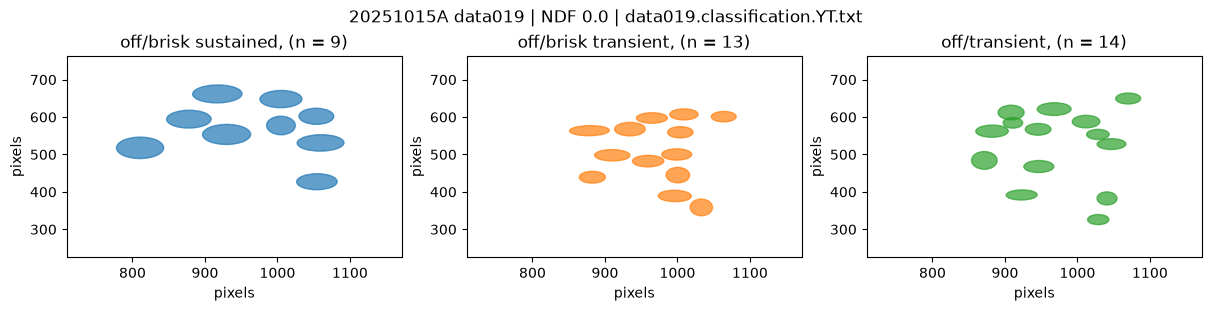

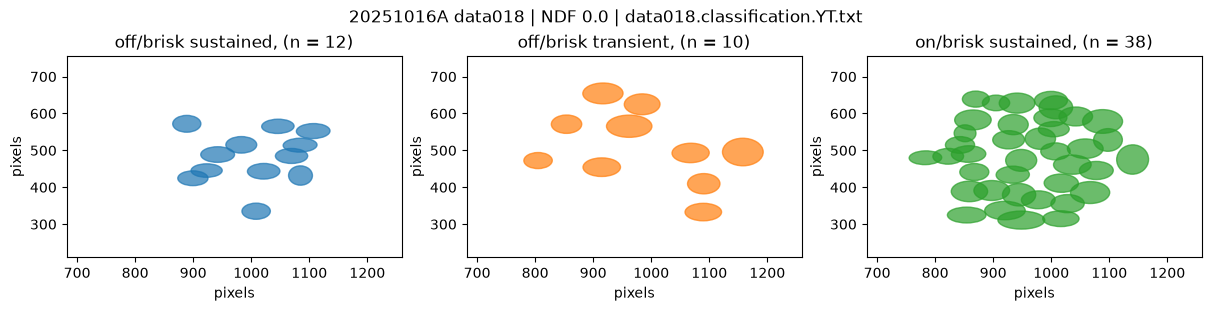

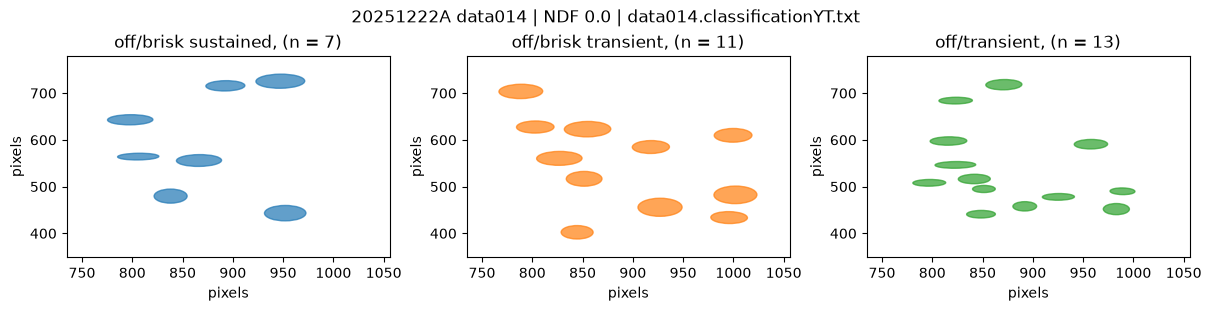

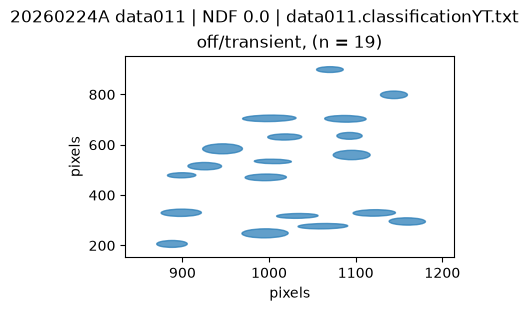

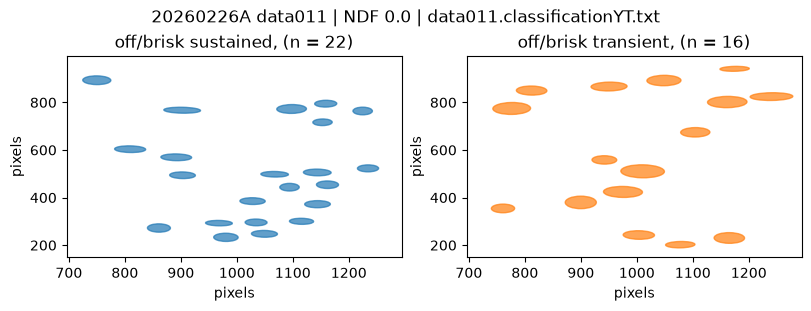

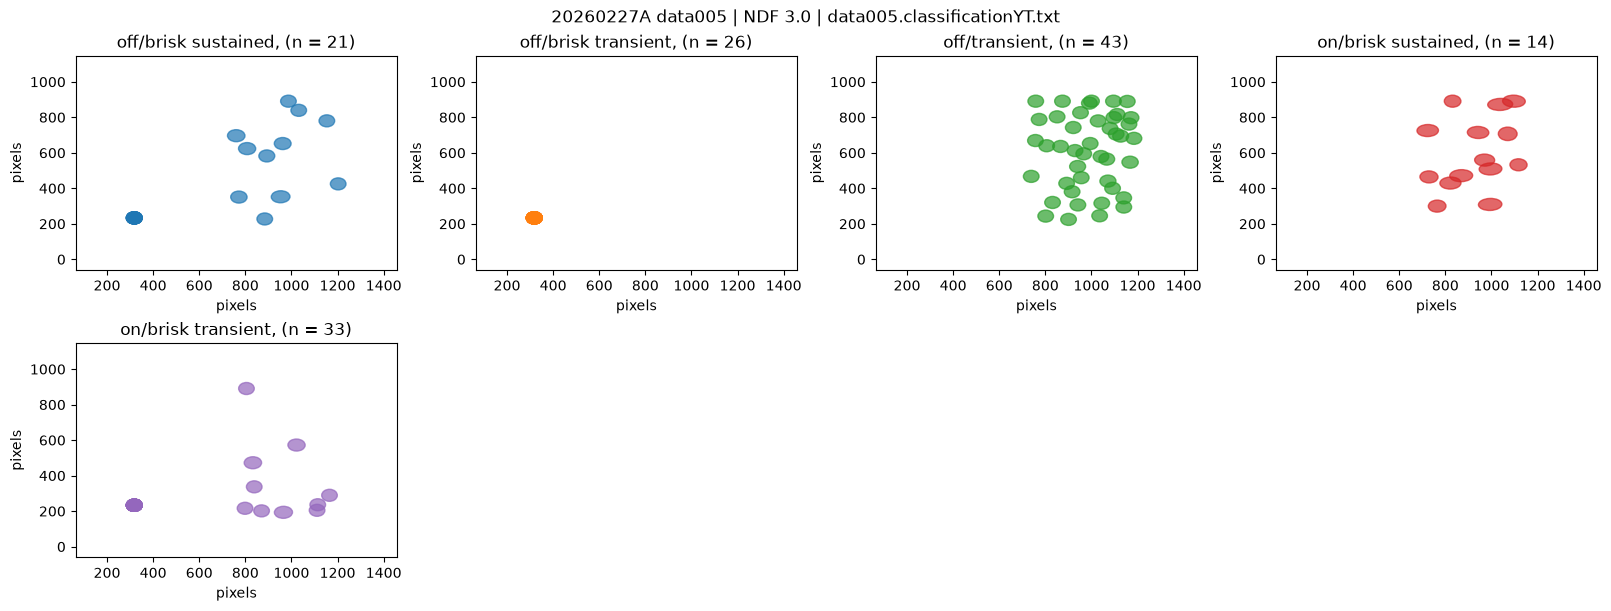

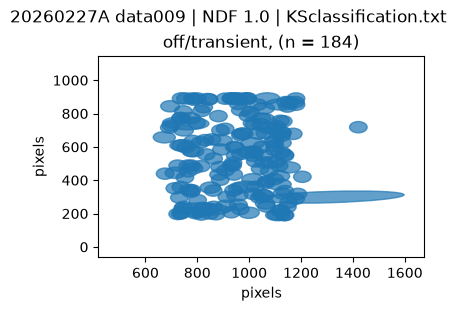

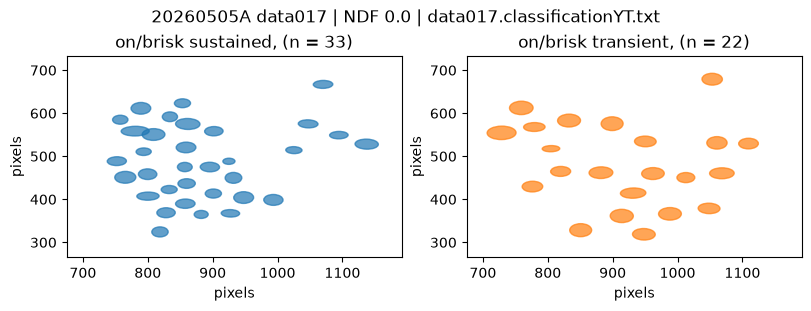

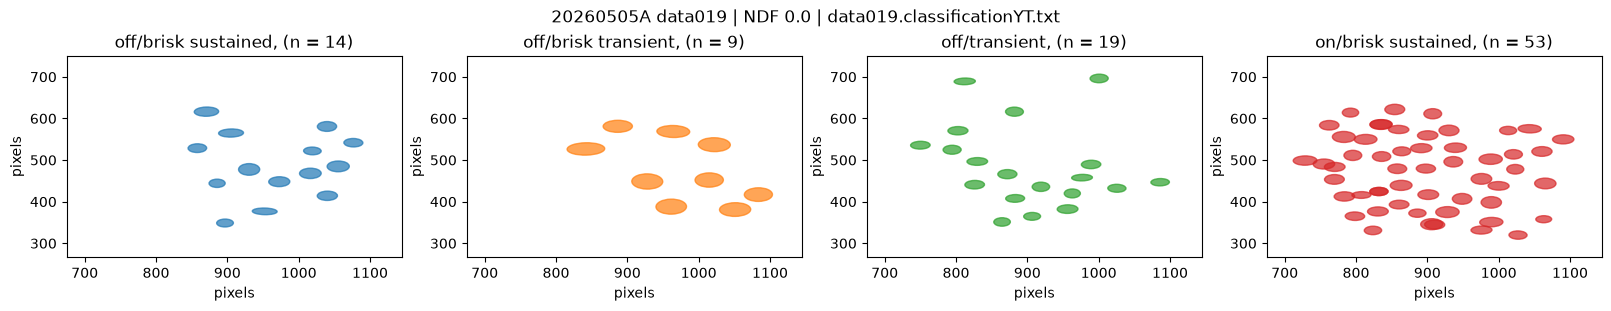

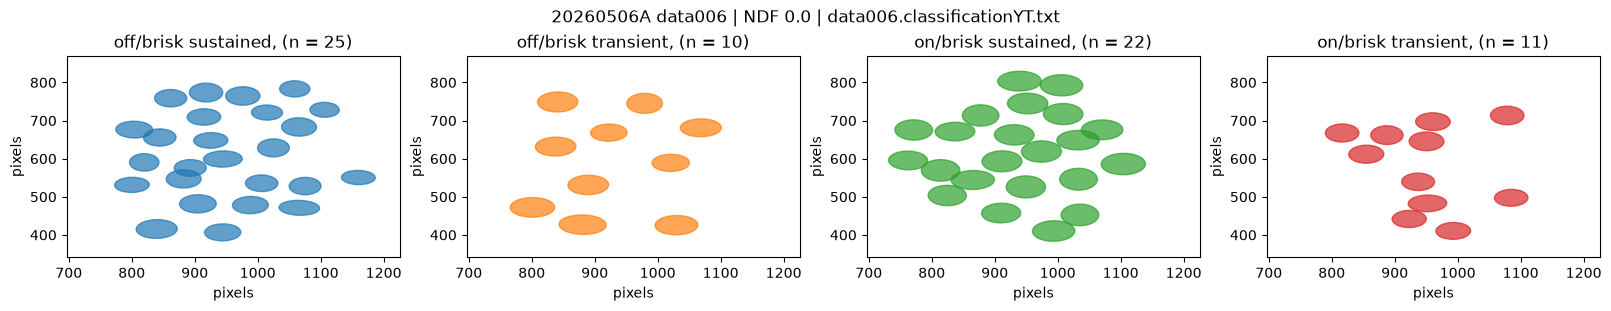

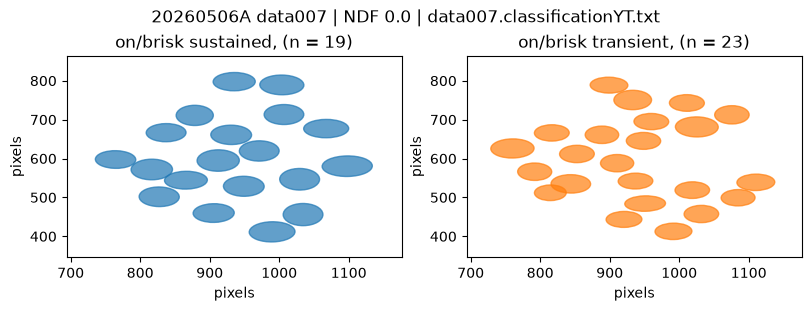

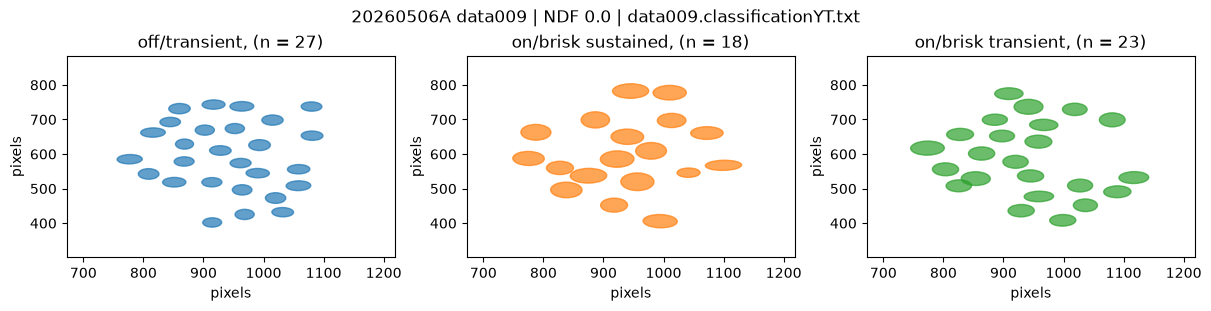

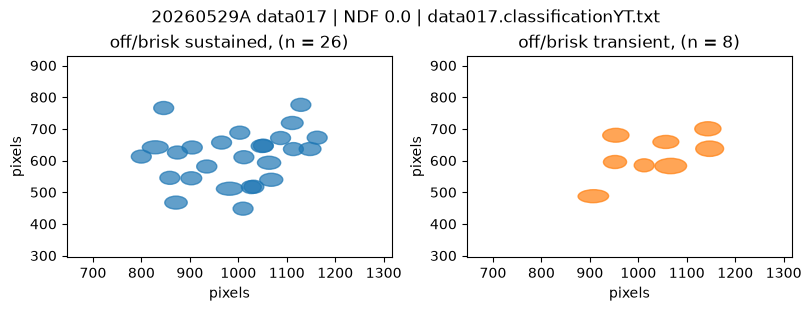

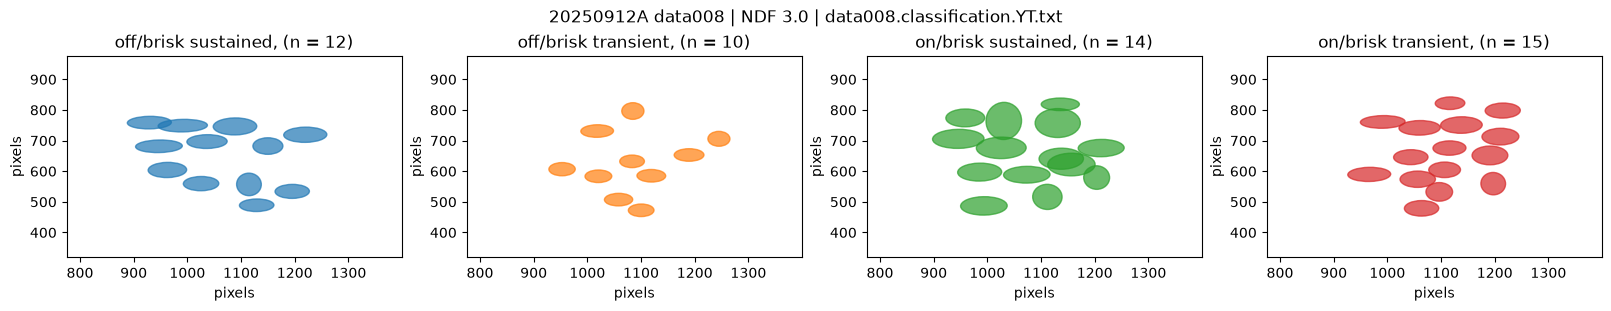

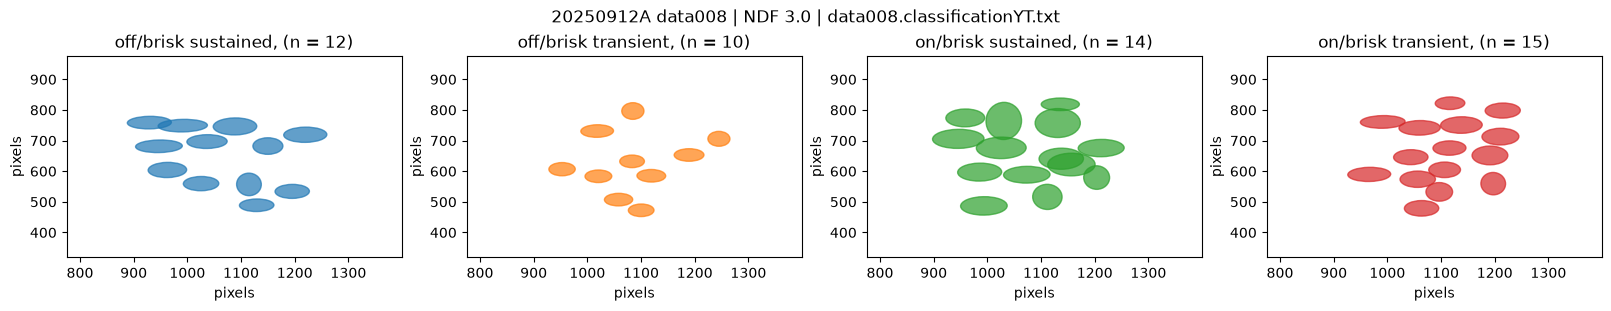

In [5]:
# cell_types is defined here for reuse further down (single-experiment analysis),
# but is intentionally NOT passed to plot_mosaics_for_datasets below: that function
# now auto-detects the cell types present in each chunk's classification file and
# drops catch-all/low-confidence labels using EXCLUDE_CELL_TYPES (edit this list if
# your lab's junk-bin naming changes). Pass cell_types=[...] to plot_mosaics_for_datasets
# instead if you want an exact list rather than auto-detect + exclude.
cell_types = ['on/brisk sustained','on/brisk transient']

# Labels to drop from the auto-detected cell type list when plotting mosaics below.
# 'nc' matches whole tokens like 'nc17'; the rest match as substrings (so 'large' also
# drops 'OnLarge', 'big' also drops 'BigMas', etc.)
EXCLUDE_CELL_TYPES = ['unknown', 'nc', 'large', 'big', 'huge', 'weak']

all_axes = ra.plot_mosaics_for_datasets(exp_search,
                                        exclude_cell_type_keywords = EXCLUDE_CELL_TYPES,
                                        minimum_n = 3, b_zoom = True)


## Choose an Experiment

In [6]:
exp_name = '20260506A'

# find_datafile_for_protocol handles experiments with more than one SpatialNoise
# datafile (e.g. 20260506A has 9) -- picks the earliest by block_id and prints every
# candidate found, so it's obvious if a different one should be picked instead.
datafile_name = ra.find_datafile_for_protocol(exp_search, exp_name)

experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary.head())

20260506A: 9 matching datafiles found: ['data000', 'data001', 'data003', 'data004', 'data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data000. Pass a different datafile_name directly if you want a different one.


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20260506A,mount1,data000,NDF 4.0,4.0,data000,manookinlab.protocols.SpatialNoise,30.20,30.20,2026-05-06 13:02:28,2026-05-06 13:32:40,20260506A\data000,319,318,1146,3407,2983,1
1,20260506A,mount1,data001,NDF 4.0,4.0,data001,manookinlab.protocols.SpatialNoise,30.25,65.25,2026-05-06 13:37:28,2026-05-06 14:07:43,20260506A\data001,319,318,1146,3408,2984,1
2,20260506A,mount1,data002,NDF 4.0,4.0,data002,manookinlab.protocols.PresentImages,18.22,140.93,2026-05-06 15:05:11,2026-05-06 15:23:24,20260506A\data002,319,318,1146,3409,2985,10
3,20260506A,mount1,data003,NDF 3.0,3.0,data003,manookinlab.protocols.SpatialNoise,30.23,187.62,2026-05-06 15:39:51,2026-05-06 16:10:05,20260506A\data003,319,318,1147,3410,2986,1
4,20260506A,mount1,data004,NDF 3.0,3.0,data004,manookinlab.protocols.SpatialNoise,30.23,229.08,2026-05-06 16:21:19,2026-05-06 16:51:33,20260506A\data004,319,318,1147,3411,2987,1


## Initialize Analysis Pipeline

In [7]:
# this assumes rigs that we do not have, inlcuding their set-up, frame rate, etc
#adding rigA now with our params
PREFERRED_TYPING_FILE = None  # e.g. 'data007.classificationYT.txt' -- set to pick a specific classification file; None auto-picks the first one found (and prints which one)
MANUAL_ANALYSIS_CHUNK = None  # e.g. 'data001' -- set to skip auto-detection

# find_classified_noise_chunk picks a white-noise chunk that actually HAS a
# classification file (preferring NDF 0, falling back to NDF 1), instead of
# create_mea_pipeline's own default "nearest chunk in time" heuristic, which can land
# on a chunk with no typing file at all (that's what was happening before this).
analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)

# create_mea_pipeline's progress/diagnostic prints (StimBlock/ResponseBlock init,
# rig config, VCD loading, warnings, etc.) collapse into one small scrollable box via
# scrollable_prints() -- doesn't change anything about the loaded pipeline.
with ra.scrollable_prints():
    pipeline = ra.create_mea_pipeline(
        exp_name, datafile_name, analysis_chunk_name=analysis_chunk_name, typing_file=PREFERRED_TYPING_FILE,
    )


20260506A: 5 classified chunks found at NDF 0: ['data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data006 (classification file(s): ['data006.classificationYT.txt']). Pass a different chunk name as analysis_chunk_name= to create_mea_pipeline if you want a different one.
  Stimulus parameters for data006:
    NDF: 0.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20260506A\data006.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 4.0
    frameDwells: [4.0, 4.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 25.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
  

## Break Out Underlying Objects

In [8]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## Show Stim Information

In [9]:
stimulus_data = stim_block.df_epochs
display(stimulus_data)

# Pull epoch block params and space constants into their own variables
# changed these labels to match ours - yasmine 07/08/2026 (we don't have 'spaceConstants')
epoch_block_params = stim_block.d_epoch_block_params
all_space_constants = epoch_block_params['stixelSizes']
space_constant = stimulus_data['epoch_parameters'].apply(
    lambda x: x['stixelSize']
).values


,epoch_index,seed,exp_name,datafile_name,group_label,protocol_name,frame_times_ms,epoch_parameters,data_dir,preTime,stimTime,tailTime,experiment_id,group_id,block_id,protocol_id,epoch_id
0,0,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289270
1,1,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289271
2,2,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289272
3,3,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289273
4,4,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289274
5,5,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289275
6,6,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289276
7,7,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289277
8,8,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289278
9,9,1.478999e+09,20260506A,data000,NDF 4.0,manookinlab.protocols.SpatialNoise,"[0.0, 16.0, 16.0, 32.0, 49.0, 65.0, 82.0, 99.0...","{'NDF': 4.0, 'amp': 'Amp1', 'amp2': '(None)', ...",20260506A\data000,250.0,175000.0,250.0,319,1146,3407,1,289279


In [10]:
#just wanted to look at what info it had
stimulus_data['epoch_parameters'].iloc[0]

{'NDF': 4.0,
 'amp': 'Amp1',
 'amp2': '(None)',
 'ndfs': '[]',
 'seed': 1478998671.0,
 'alpha': 1.0,
 'preTime': 250.0,
 'contrast': 1.0,
 'gridSize': 25.0,
 'stimTime': 175000.0,
 'tailTime': 250.0,
 'frameRate': 59.0,
 'lightPath': 'below',
 'lpfCutoff': 10000.0,
 'ndfValues': [1.0, 2.0, 3.0, 4.0, 5.0, 0.0],
 'numFrames': 10340.0,
 'prerender': 0,
 'appVersion': None,
 'canvasSize': [1824.0, 1140.0],
 'dspVersion': None,
 'frameDwell': 4.0,
 'numXChecks': 166.0,
 'numYChecks': 104.0,
 'pre_frames': 15.0,
 'repeatTime': 10000.0,
 'sampleRate': 1000.0,
 'stixelSize': 100.0,
 'uniqueTime': 165000.0,
 'frameDwells': [4.0, 4.0],
 'numXStixels': 43.0,
 'numYStixels': 27.0,
 'scaleFactor': 0.5,
 'stixelSizes': [100.0, 100.0],
 'centerOffset': [0.0, 0.0],
 'dataFileName': '20260506A\\data000.bin',
 'hardwareType': 'MCTG_HW_TYPE_MC700B',
 'serialNumber': None,
 'operatingMode': 'VClamp',
 'repeat_frames': 600.0,
 'unique_frames': 9900.0,
 'chromaticClass': 'achromatic',
 'gaussianFilter': 0,


## Pull Spike Times and Spike Counts

In [11]:
spike_times = ra.get_spike_xarr(response_block, cell_types = cell_types, minimum_n = 3)
spike_counts = xr.apply_ufunc(len, spike_times, vectorize = True)

# Bonus: Use apply_ufunc to pull the average baseline spike count from the 'pre time' portion of the stimulus
def get_avg_baseline(arr, pre_time):
    pre_spikes = [spike for spike in arr if spike < pre_time]

    return len(pre_spikes)

pre_time = epoch_block_params['preTime']
baseline_spike_counts = xr.apply_ufunc(get_avg_baseline, spike_times, 
                                       kwargs = {'pre_time' : pre_time},
                                       vectorize = True)
